In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import re
from collections import Counter

In [3]:
# from aquarel import load_theme

In [4]:
"""theme = load_theme("solarized_dark")
theme.apply()
theme.apply_transforms()

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']"""

'theme = load_theme("solarized_dark")\ntheme.apply()\ntheme.apply_transforms()\n\nplt.rcParams[\'font.family\'] = \'DejaVu Sans\'\nplt.rcParams[\'font.sans-serif\'] = [\'DejaVu Sans\']'

In [5]:
"""import matplotlib.style as mplstyle
mplstyle.core.USER_LIBRARY_PATHS.append('/home/kb/anaconda3/envs/myenv/lib/python3.13/site-packages/aquarel/styles')"""

"import matplotlib.style as mplstyle\nmplstyle.core.USER_LIBRARY_PATHS.append('/home/kb/anaconda3/envs/myenv/lib/python3.13/site-packages/aquarel/styles')"

In [6]:
"""theme = load_theme("solarized_dark")
theme.apply()
theme.apply_transforms()

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']"""

'theme = load_theme("solarized_dark")\ntheme.apply()\ntheme.apply_transforms()\n\nplt.rcParams[\'font.family\'] = \'DejaVu Sans\'\nplt.rcParams[\'font.sans-serif\'] = [\'DejaVu Sans\']'

In [7]:
"""plt.style.use('./rose-pine-moon.mplstyle')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']"""

"plt.style.use('./rose-pine-moon.mplstyle')\nplt.rcParams['font.family'] = 'DejaVu Sans'\nplt.rcParams['font.sans-serif'] = ['DejaVu Sans']"

In [8]:
"""theme = load_theme("solarized_light")
theme.apply()
theme.apply_transforms()

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']"""

'theme = load_theme("solarized_light")\ntheme.apply()\ntheme.apply_transforms()\n\nplt.rcParams[\'font.family\'] = \'DejaVu Sans\'\nplt.rcParams[\'font.sans-serif\'] = [\'DejaVu Sans\']'

In [9]:
def Classification_Report(y_pred, y_test):
    y_pred = np.asarray(y_pred)
    y_test = np.asarray(y_test)

    tp = np.sum((y_pred == 1) & (y_test == 1))
    tn = np.sum((y_pred == 0) & (y_test == 0))
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

# Data Pre-Processing

In [10]:
df1 = pd.read_csv("spam.csv", encoding="latin-1")

In [11]:
df1 = pd.read_csv("spam.csv", encoding="latin-1", usecols=[0,1], names=["label","message"], header=0)

In [12]:
df1.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df1.shape

(5572, 2)

In [14]:
df1.nunique()

label         2
message    5169
dtype: int64

In [15]:
df1["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [16]:
df2 = pd.read_csv("spam2.csv")

In [17]:
"""def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.split()"""

'def tokenize(text):\n    text = text.lower()\n    text = re.sub(r"[^a-z0-9]+", " ", text)\n    return text.split()'

In [18]:
"""df2_fixed = df2.rename(columns={"text": "message"})
df = pd.concat([df1, df2_fixed], ignore_index=True)
"""

'df2_fixed = df2.rename(columns={"text": "message"})\ndf = pd.concat([df1, df2_fixed], ignore_index=True)\n'

In [19]:
df=df1

In [20]:
df.shape

(5572, 2)

In [21]:
def tokenize(text):
    text = text.lower()
    clean = []
    for ch in text:
        if ch.isalnum():
            clean.append(ch)
        else:
            clean.append(" ")
    return "".join(clean).split()


In [22]:
tokenize("Karthik Balaji")

['karthik', 'balaji']

In [23]:
spam_words = []
ham_words = []

In [24]:
for label, msg in zip(df["label"], df["message"]):
    words = tokenize(msg)
    if label == "spam":
        spam_words.extend(words)
    else:
        ham_words.extend(words)

In [25]:
spam_counts = Counter(spam_words)
ham_counts = Counter(ham_words)

N = 600

A = set([w for w,_ in spam_counts.most_common(N)])
B = set([w for w,_ in ham_counts.most_common(N)])

spam_indicator_words = A - B
ham_indicator_words = B - A


In [26]:
print(len(spam_indicator_words))
print(len(ham_indicator_words))

389
389


In [27]:
top_N = 200

In [28]:
top_spam = list(spam_indicator_words)[:top_N]
top_ham = list(ham_indicator_words)[:top_N]


cols_spam = {
    f"spam_{w}": df["message"].apply(lambda x: tokenize(x).count(w))
    for w in top_spam
}

cols_ham = {
    f"ham_{w}": df["message"].apply(lambda x: tokenize(x).count(w))
    for w in top_ham
}

df = pd.concat([df, pd.DataFrame(cols_spam), pd.DataFrame(cols_ham)], axis=1).copy()

In [29]:
from sklearn.utils import resample

df_major = df[df.label == "ham"]
df_minor = df[df.label == "spam"]

df_minor_up = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

df_balanced = pd.concat([df_major, df_minor_up]).sample(frac=1, random_state=42)


In [30]:
df_balanced["label"].value_counts()

label
ham     4825
spam    4825
Name: count, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [32]:

X = df_balanced.drop(columns=["label", "message"])
y = df_balanced["label"].map({"ham":0, "spam":1})

In [33]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM (Library)

In [34]:

svm_model = SVC(kernel="linear")
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
y_pred = svm_model.predict(X_test)

In [36]:
svm_report = Classification_Report(y_pred, y_test)

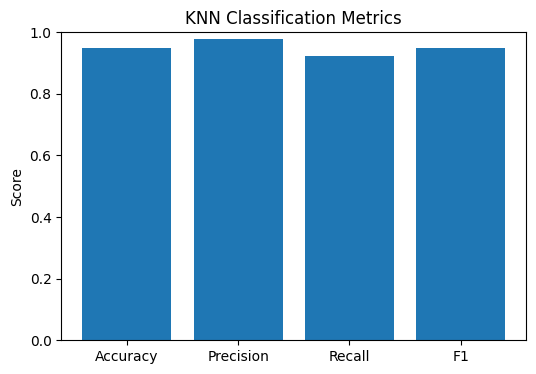

In [37]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [svm_report[m] for m in metrics]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylabel("Score")
plt.title("KNN Classification Metrics")
plt.ylim(0, 1)
plt.show()

# KNN

In [38]:
class KNN():
    def __init__(self):
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y, k=3):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        self.k = k

    def euclidean(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2, axis=1))

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []
        for x in X:
            dists = self.euclidean(self.X_train, x)
            indices = np.argsort(dists)
            top_k = indices[:self.k]
            labels = self.y_train[top_k]
            values, counts = np.unique(labels, return_counts=True)
            preds.append(values[np.argmax(counts)])
        return np.array(preds)


In [39]:
KNN_Model = KNN()

In [40]:
KNN_Model.fit(X_train, y_train)
y_pred = KNN_Model.predict(X_test)

In [41]:
y_pred

array([1, 0, 1, ..., 0, 1, 1], shape=(1930,))

In [42]:
np.count_nonzero(y_pred)

np.int64(931)

In [43]:
knn_report = Classification_Report(y_pred, y_test)

In [44]:
knn_report

{'TP': np.int64(905),
 'TN': np.int64(939),
 'FP': np.int64(26),
 'FN': np.int64(60),
 'Accuracy': np.float64(0.9554404145077721),
 'Precision': np.float64(0.9720730397422127),
 'Recall': np.float64(0.9378238341968912),
 'F1': np.float64(0.9546413502109704)}

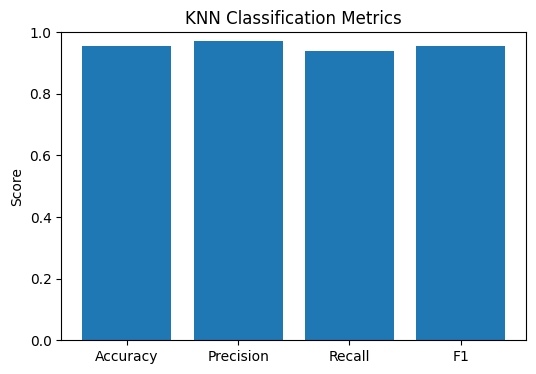

In [45]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [knn_report[m] for m in metrics]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylabel("Score")
plt.title("KNN Classification Metrics")
plt.ylim(0, 1)
plt.show()

In [46]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_priors = None
        self.feature_probs = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        classes = np.unique(y)
        self.class_priors = {}
        self.feature_probs = {}

        for c in classes:
            X_c = X[y == c]
            self.class_priors[c] = (len(X_c) + self.alpha) / (len(X) + 2 * self.alpha)
            self.feature_probs[c] = (np.sum(X_c, axis=0) + self.alpha) / (len(X_c) + 2 * self.alpha)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = []

        for x in X:
            scores = {}
            for c in self.class_priors:
                # log space
                log_prior = np.log(self.class_priors[c])
                log_likelihood = np.sum(
                    x * np.log(self.feature_probs[c]) +
                    (1 - x) * np.log(1 - self.feature_probs[c])
                )
                scores[c] = log_prior + log_likelihood
            preds.append(max(scores, key=scores.get))

        return np.array(preds)

In [47]:
NB_Model = NaiveBayes()

In [48]:
NB_Model.fit(X_train,y_train)

In [49]:
y_pred = NB_Model.predict(X_test)

In [50]:
y_pred

array([1, 0, 0, ..., 0, 1, 1], shape=(1930,))

In [51]:
nb_report = Classification_Report(y_pred, y_test)

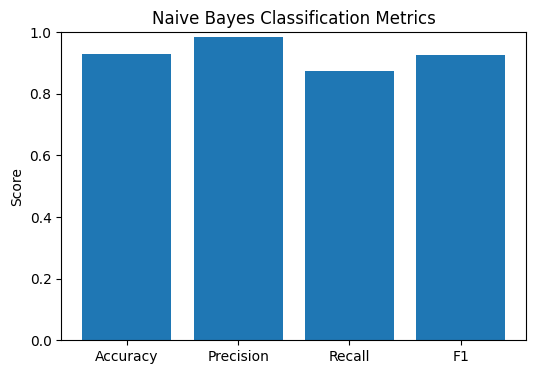

In [52]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [nb_report[m] for m in metrics]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylabel("Score")
plt.title("Naive Bayes Classification Metrics")
plt.ylim(0, 1)
plt.show()